In [1]:
from skimage import data
from skimage import transform as tf
from skimage.feature import CENSURE
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

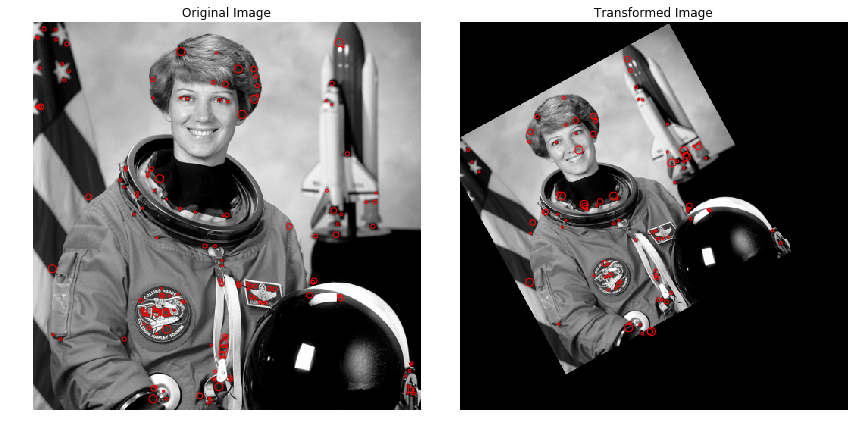

In [2]:
#  scale-invariant center-surround detector

img_orig = rgb2gray(data.astronaut())
tform = tf.AffineTransform(scale=(1.5, 1.5),
                          rotation=0.5,
                          translation=(150, -200))
img_warp = tf.warp(img_orig, tform)

detector = CENSURE()

fig, ax = plt.subplots(nrows=1, ncols=2, 
                       figsize=(12, 6))

detector.detect(img_orig)

ax[0].imshow(img_orig, cmap=plt.cm.gray)

ax[0].scatter(detector.keypoints[:, 1],
              detector.keypoints[:, 0],
              2 ** detector.scales,
              facecolors='none',
              edgecolors='r')

ax[0].set_title("Original Image")

detector.detect(img_warp)

ax[1].imshow(img_warp, cmap=plt.cm.gray)

ax[1].scatter(detector.keypoints[:, 1],
              detector.keypoints[:, 0],
              2 ** detector.scales,
              facecolors='none',
              edgecolors='r')

ax[1].set_title('Transformed Image')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()